         Date                 Event        Fighter1       Fighter2  \
0  1993-11-12  UFC 1: The Beginning    Royce Gracie  Art Jimmerson   
1  1993-11-12  UFC 1: The Beginning    Kevin Rosier   Zane Frazier   
2  1993-11-12  UFC 1: The Beginning  Gerard Gordeau     Teila Tuli   
3  1993-11-12  UFC 1: The Beginning   Jason DeLucia  Trent Jenkins   
4  1993-11-12  UFC 1: The Beginning    Ken Shamrock  Patrick Smith   

                          Method Note Result  Round  Time  Time (secs)  \
0             Submission (mount)    -   def.    1.0  2:18          138   
1          TKO (corner stoppage)    -   def.    1.0  4:20          260   
2                TKO (head kick)    -   def.    1.0  0:26           26   
3  Submission (rear-naked choke)    -   def.    1.0  0:52           52   
4         Submission (heel hook)    -   def.    1.0  1:49          109   

  Weight class  Cluster  
0            -        1  
1            -        3  
2            -        3  
3            -        1  
4   

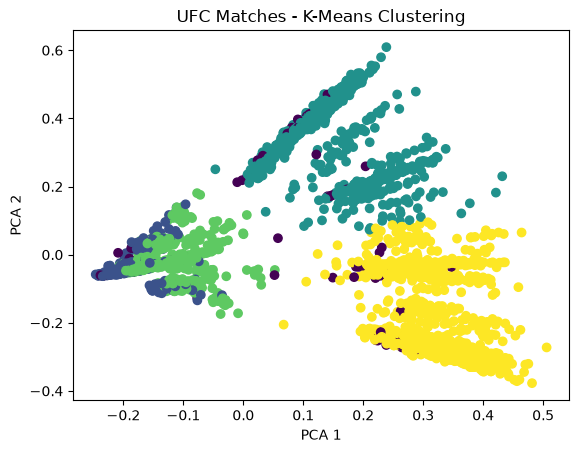


Saved: ufc_matches_kmeans.csv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("ufc_matches_to_date_may13.csv")

# NLP: combine all columns into text
text = df.fillna("").astype(str).agg(" ".join, axis=1)

# TF-IDF
vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
X = vectorizer.fit_transform(text)

# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# Display results
print(df.head())
print("\nCluster counts:")
print(df["Cluster"].value_counts())

# Visualisation
X2 = PCA(n_components=2).fit_transform(X.toarray())
plt.scatter(X2[:,0], X2[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("UFC Matches - K-Means Clustering")
plt.show()

# Save
df.to_csv("ufc_matches_kmeans.csv", index=False)
print("\nSaved: ufc_matches_kmeans.csv")